# 01 — Exploration des données : Taux de chômage canadien

**Source** : Statistique Canada, Table 14-10-0287-03 — Caractéristiques de la population active, données mensuelles, désaisonnalisées  
**Licence** : Licence du gouvernement ouvert — Canada  
**URL** : https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1410028703  
**Date de téléchargement** : Mars 2026  

## Objectif
Explorer les données de chômage mensuel (national + 10 provinces) pour comprendre :
- Les tendances de long terme
- La saisonnalité résiduelle
- L'impact des chocs (2008, COVID-19)
- Les différences interprovinciales

In [1]:
# Configuration et imports
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import (
    download_statcan_table, filter_unemployment_rate,
    PROVINCES, PROVINCES_FR, DATA_RAW, DATA_PROCESSED
)

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print('Imports OK')

Imports OK


## 1. Téléchargement des données brutes

On télécharge la table complète depuis StatCan (fichier ZIP ~100 MB).  
Le fichier est mis en cache localement dans `data/raw/` pour les exécutions suivantes.

In [2]:
# Telecharger la table StatCan (cache local apres le 1er telechargement)
df_raw = download_statcan_table()

# Apercu de la structure
print(f"\nShape : {df_raw.shape}")
print(f"Colonnes : {list(df_raw.columns)}")
df_raw.head(3)

Fichier deja present : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/data/raw/14100287.csv
Chargement depuis le cache local...


Shape : (5448546, 19)

Shape : (5448546, 19)
Colonnes : ['REF_DATE', 'GEO', 'DGUID', 'Labour force characteristics', 'Gender', 'Age group', 'Statistics', 'Data type', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'VALUE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']


,REF_DATE,GEO,DGUID,Labour force characteristics,Gender,Age group,Statistics,Data type,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1976-01,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v2062809,1.1.1.1.1.1,16852.4,NaN,NaN,NaN,1
1,1976-01,Canada,2021A000011124,Population,Total - Gender,15 years and over,Estimate,Unadjusted,Persons in thousands,428,thousands,3,v2064888,1.1.1.1.1.2,16852.4,NaN,NaN,NaN,1
2,1976-01,Canada,2021A000011124,Population,Total - Gender,15 to 64 years,Estimate,Seasonally adjusted,Persons in thousands,428,thousands,3,v21580997,1.1.1.8.1.1,15015.9,NaN,NaN,NaN,1


In [3]:
# Quels indicateurs sont disponibles dans cette table?
print("Indicateurs disponibles :")
print(df_raw['Labour force characteristics'].unique())

Indicateurs disponibles :
<ArrowStringArray>
[          'Population',         'Labour force',           'Employment',
 'Full-time employment', 'Part-time employment',         'Unemployment',
    'Unemployment rate',   'Participation rate',      'Employment rate']
Length: 9, dtype: str


## 2. Filtrage : taux de chômage uniquement

On ne garde que :
- **Indicateur** : Unemployment rate (taux de chômage)
- **Sexe** : Les deux sexes combinés
- **Âge** : 15 ans et plus
- **Géographies** : Canada + 10 provinces

In [4]:
# Filtrer pour le taux de chomage
df = filter_unemployment_rate(df_raw)

# Diagnostics
print(f"\nValeurs manquantes : {df['unemployment_rate'].isna().sum()}")
print(f"\nStatistiques descriptives :")
df.groupby('geo')['unemployment_rate'].describe().round(1)

Apres filtrage : 6666 observations
Periode : 1976-01-01 00:00:00 a 2026-06-01 00:00:00
Geographies : 11 (Alberta, British Columbia, Canada, Manitoba, New Brunswick, Newfoundland and Labrador, Nova Scotia, Ontario, Prince Edward Island, Quebec, Saskatchewan)

Valeurs manquantes : 0

Statistiques descriptives :


,count,mean,std,min,25%,50%,75%,max
geo,,,,,,,,
Alberta,606.0,6.6,2.2,3.2,4.8,6.3,8.0,15.4
British Columbia,606.0,8.0,2.6,4.1,6.1,7.8,9.0,15.7
Canada,606.0,8.0,1.7,4.8,6.9,7.6,8.9,14.2
Manitoba,606.0,6.3,1.5,3.9,5.2,5.7,7.4,11.9
New Brunswick,606.0,10.7,2.2,5.9,9.3,10.5,12.4,16.5
Newfoundland and Labrador,606.0,15.3,2.9,8.2,13.2,15.4,17.5,22.7
Nova Scotia,606.0,9.9,2.1,5.4,8.5,9.6,11.3,15.7
Ontario,606.0,7.4,1.6,4.7,6.3,7.0,8.3,14.2
Prince Edward Island,606.0,11.8,2.5,5.7,10.2,11.5,13.1,18.9


## 3. Tendances nationales

Visualisation du taux de chômage canadien sur toute la période disponible.

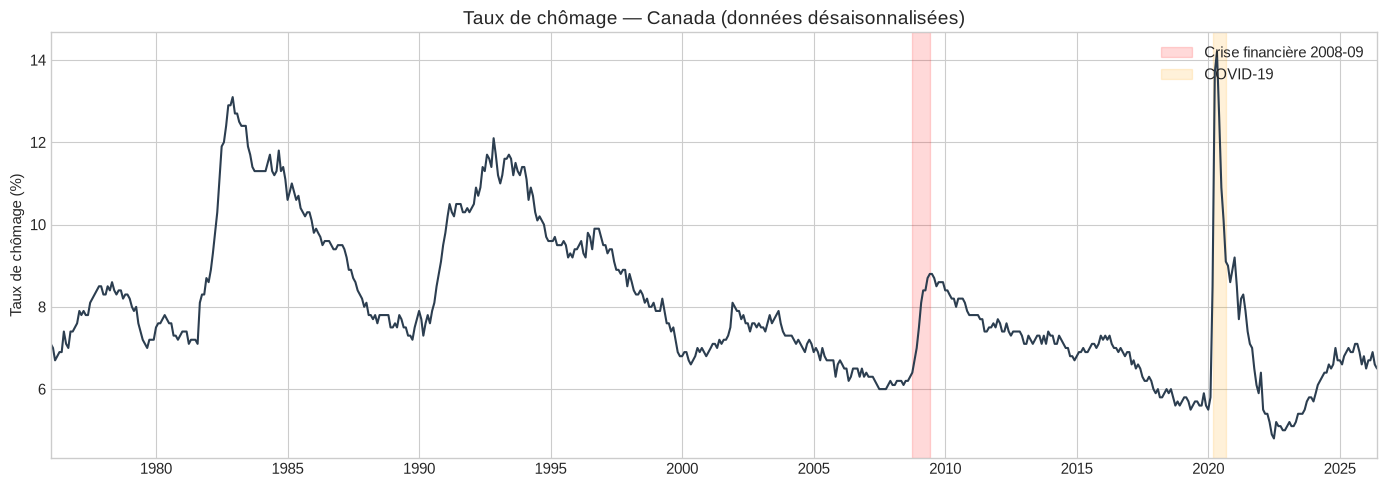

In [5]:
# Taux de chomage national
canada = df[df['geo'] == 'Canada'].set_index('date')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(canada.index, canada['unemployment_rate'], color='#2c3e50', linewidth=1.5)

# Annoter les chocs majeurs
ax.axvspan('2008-10-01', '2009-06-01', alpha=0.15, color='red', label='Crise financière 2008-09')
ax.axvspan('2020-03-01', '2020-09-01', alpha=0.15, color='orange', label='COVID-19')

ax.set_title('Taux de chômage — Canada (données désaisonnalisées)', fontsize=14)
ax.set_ylabel('Taux de chômage (%)')
ax.legend(loc='upper right')
ax.set_xlim(canada.index.min(), canada.index.max())
plt.tight_layout()
plt.show()

## 4. Comparaison interprovinciale

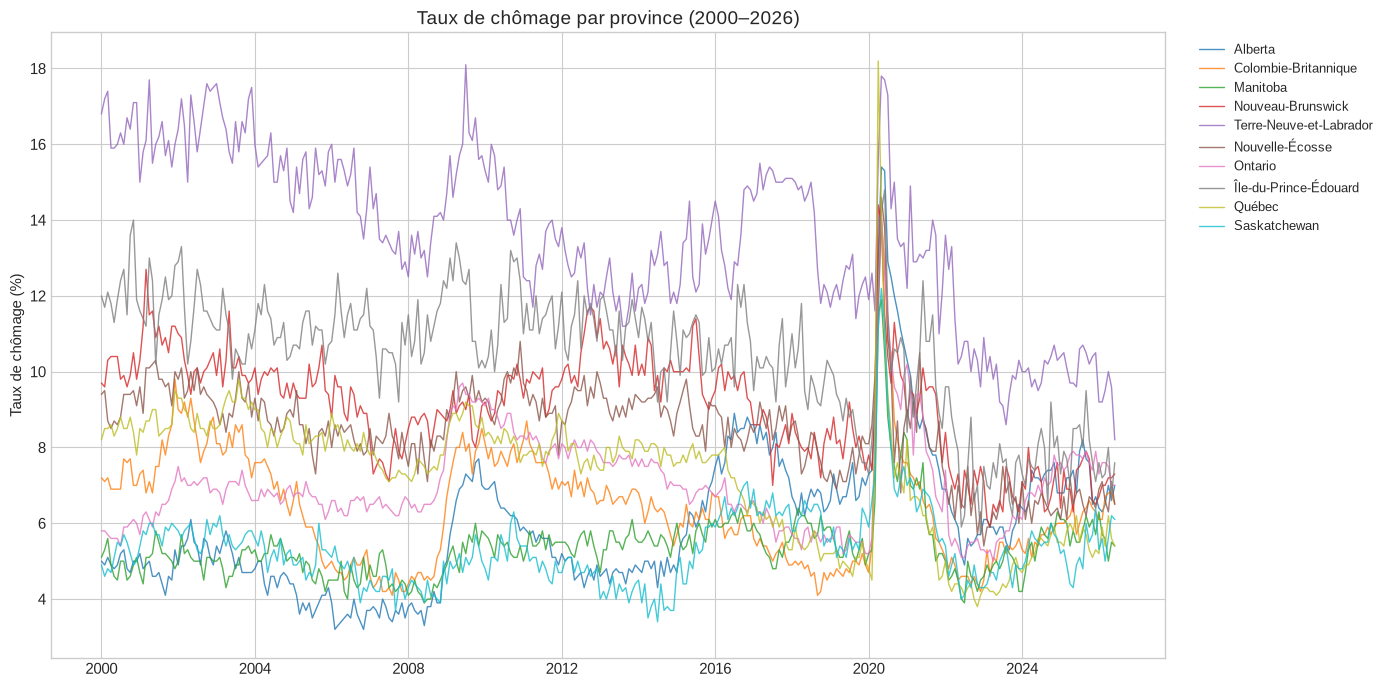

In [6]:
# Taux de chomage par province (depuis 2000 pour lisibilite)
df_2000 = df[(df['date'] >= '2000-01-01') & (df['geo'] != 'Canada')]

fig, ax = plt.subplots(figsize=(14, 7))
for prov in PROVINCES:
    subset = df_2000[df_2000['geo'] == prov]
    ax.plot(subset['date'], subset['unemployment_rate'],
            label=PROVINCES_FR.get(prov, prov), alpha=0.8, linewidth=1)

ax.set_title('Taux de chômage par province (2000–2026)', fontsize=14)
ax.set_ylabel('Taux de chômage (%)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

/tmp/ipykernel_2385/4162305395.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_prov, x='province_fr', y='unemployment_rate',
/tmp/ipykernel_2385/4162305395.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


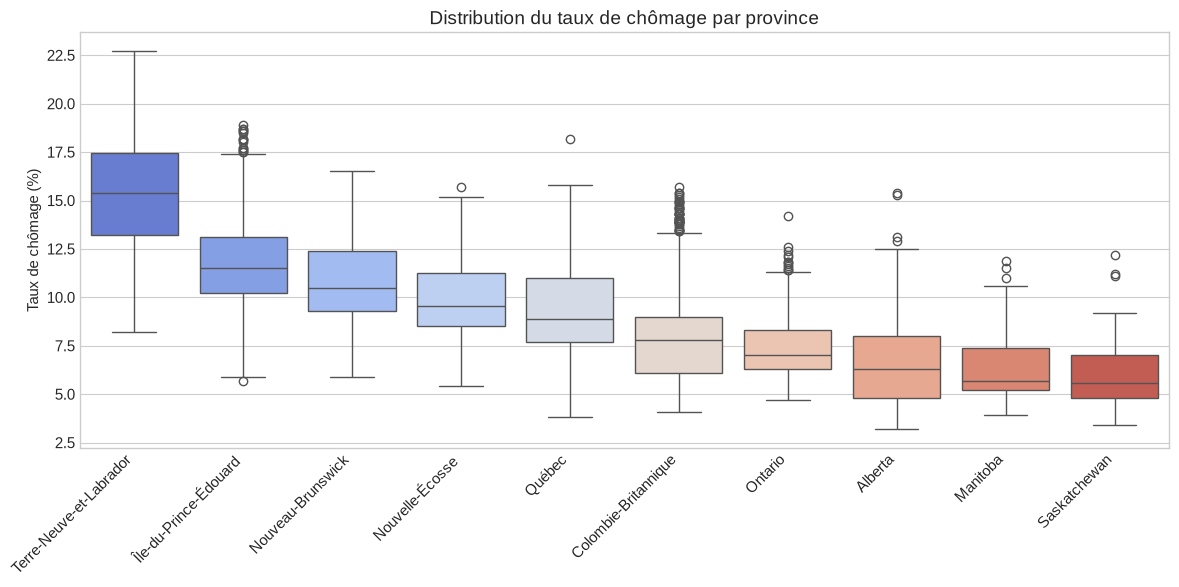

In [7]:
# Distribution du taux de chomage par province (boxplot)
df_prov = df[df['geo'] != 'Canada'].copy()
df_prov['province_fr'] = df_prov['geo'].map(PROVINCES_FR)

# Ordonner par mediane
order = (df_prov.groupby('province_fr')['unemployment_rate']
         .median().sort_values(ascending=False).index)

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_prov, x='province_fr', y='unemployment_rate',
            order=order, palette='coolwarm', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('Distribution du taux de chômage par province', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('Taux de chômage (%)')
plt.tight_layout()
plt.show()

## 5. Analyse de la saisonnalité et autocorrélation

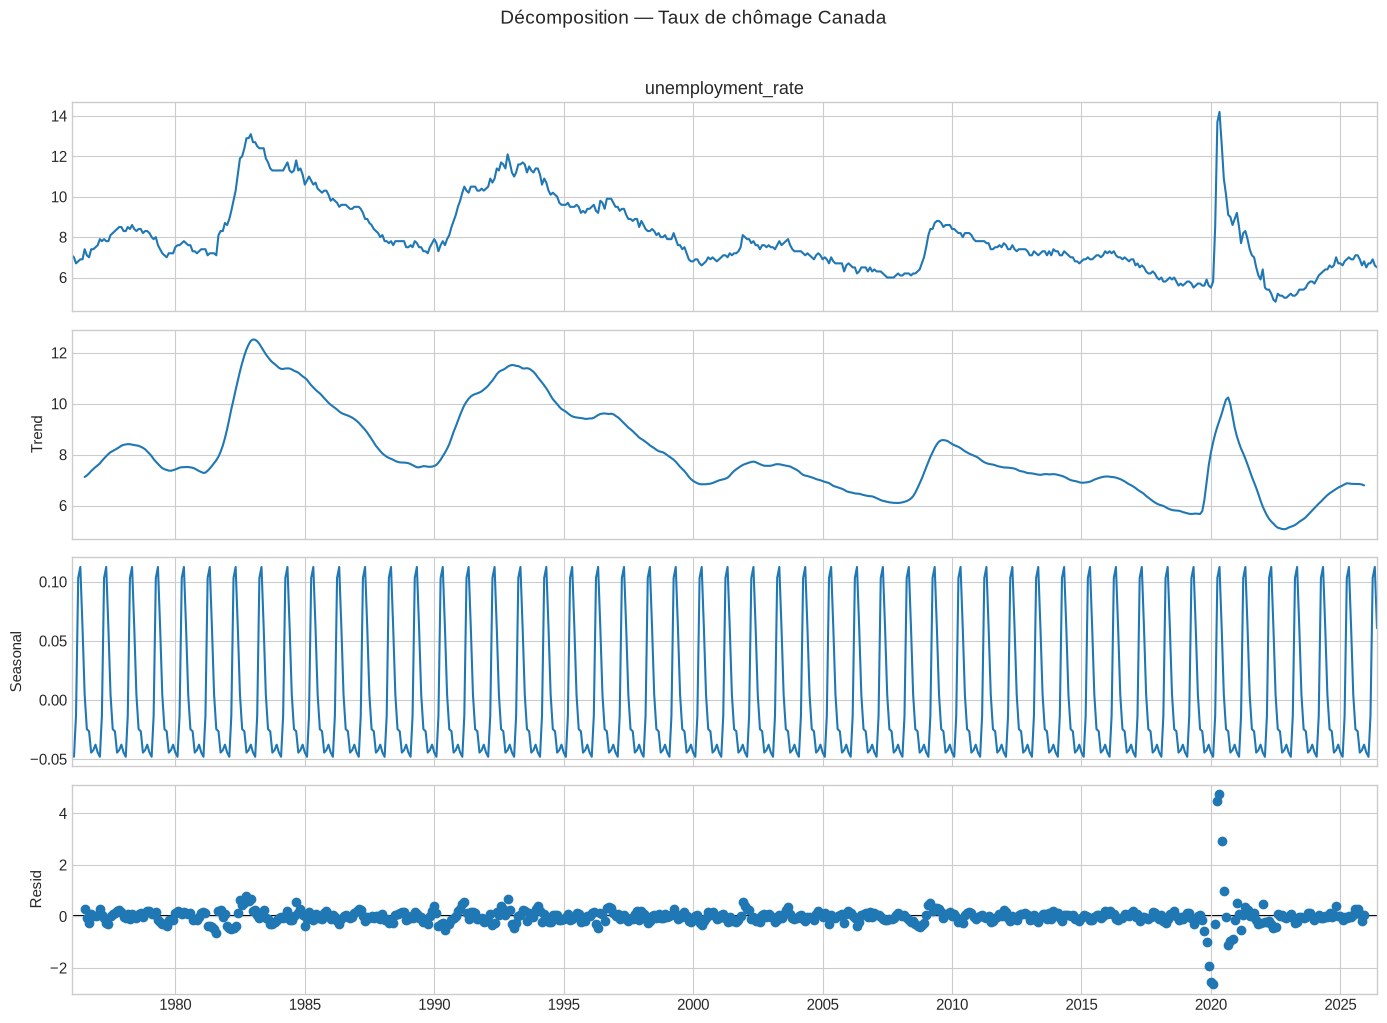

In [8]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

# Decomposition du taux de chomage national
canada_ts = canada['unemployment_rate'].dropna()

# Meme si les donnees sont desaisonnalisees, verifions
decomposition = seasonal_decompose(canada_ts, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Décomposition — Taux de chômage Canada', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

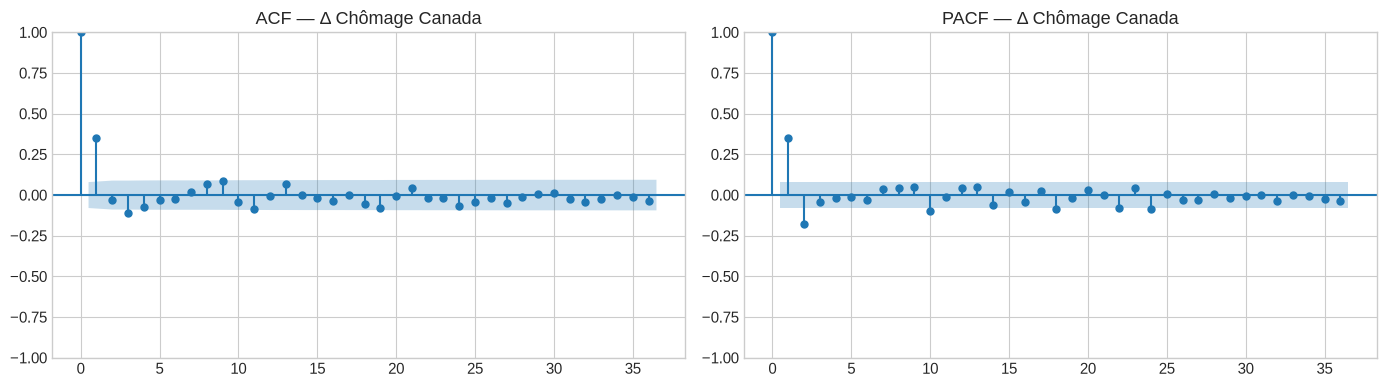

L'ACF et la PACF en différences premières guideront le choix des ordres (p, d, q) pour ARIMA.


In [9]:
# ACF et PACF — utiles pour le choix des parametres ARIMA
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(canada_ts.diff().dropna(), lags=36, ax=axes[0], title='ACF — Δ Chômage Canada')
plot_pacf(canada_ts.diff().dropna(), lags=36, ax=axes[1], title='PACF — Δ Chômage Canada')

plt.tight_layout()
plt.show()

print("L'ACF et la PACF en différences premières guideront le choix des ordres (p, d, q) pour ARIMA.")

## 6. Tests de stationnarité

Avant la modélisation ARIMA, on vérifie si la série est stationnaire.

In [10]:
from statsmodels.tsa.stattools import adfuller, kpss

def test_stationarity(series, name=''):
    """Effectue les tests ADF et KPSS et affiche les resultats."""
    # Test ADF (H0 : racine unitaire = non stationnaire)
    adf_result = adfuller(series.dropna(), autolag='AIC')
    print(f"=== Tests de stationnarité : {name} ===")
    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"p-value       : {adf_result[1]:.4f}")
    print(f"Conclusion ADF: {'Stationnaire' if adf_result[1] < 0.05 else 'Non stationnaire'} (seuil 5%)")
    
    # Test KPSS (H0 : stationnaire)
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\nKPSS Statistic: {kpss_result[0]:.4f}")
    print(f"p-value       : {kpss_result[1]:.4f}")
    print(f"Conclusion KPSS: {'Stationnaire' if kpss_result[1] > 0.05 else 'Non stationnaire'} (seuil 5%)")
    print()

# Test en niveau
test_stationarity(canada_ts, 'Niveau')

# Test en differences premieres
test_stationarity(canada_ts.diff().dropna(), 'Différences premières')

=== Tests de stationnarité : Niveau ===
ADF Statistic : -2.8893
p-value       : 0.0466
Conclusion ADF: Stationnaire (seuil 5%)

KPSS Statistic: 1.5026
p-value       : 0.0100
Conclusion KPSS: Non stationnaire (seuil 5%)

=== Tests de stationnarité : Différences premières ===
ADF Statistic : -16.6666
p-value       : 0.0000
Conclusion ADF: Stationnaire (seuil 5%)

KPSS Statistic: 0.0464
p-value       : 0.1000
Conclusion KPSS: Stationnaire (seuil 5%)



/tmp/ipykernel_2385/834569552.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
/tmp/ipykernel_2385/834569552.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')


## 7. Sauvegarde des données nettoyées

In [11]:
# Sauvegarder le dataset filtre pour les notebooks suivants
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
output_path = DATA_PROCESSED / 'chomage_mensuel.csv'
df.to_csv(output_path, index=False)
print(f"Donnees sauvegardees : {output_path}")
print(f"Shape finale : {df.shape}")
print(f"\nApercu :")
df.tail(5)

Donnees sauvegardees : /home/runner/work/forecasting-chomage-canada/forecasting-chomage-canada/data/processed/chomage_mensuel.csv
Shape finale : (6666, 3)

Apercu :


,date,geo,unemployment_rate
6661,2026-02-01,Saskatchewan,5.6
6662,2026-03-01,Saskatchewan,5.0
6663,2026-04-01,Saskatchewan,5.6
6664,2026-05-01,Saskatchewan,6.2
6665,2026-06-01,Saskatchewan,6.1


## Observations clés

- **Tendance générale** : Le chômage au Canada a connu une baisse tendancielle depuis les années 2000, interrompue par deux chocs majeurs (2008-09, 2020).
- **Hétérogénéité provinciale** : Les provinces atlantiques affichent historiquement des taux plus élevés que l'Ontario, le Québec ou les provinces de l'Ouest.
- **Choc COVID** : Pic sans précédent en 2020, suivi d'une reprise rapide — ce choc est un défi pour les modèles de prévision.
- **Stationnarité** : La série en niveau est probablement non stationnaire (à confirmer par les tests) → ARIMA nécessitera au moins une différenciation (d=1).

---
*Prochaine étape → Notebook 02 : nettoyage et préparation des données pour Prophet et ARIMA.*